# Sit and wire things: the release of energy
### where the joules go when a capacitor and an inductor let go

A charged **capacitor** and a current-carrying **inductor** are energy tanks:
$$E_C=\tfrac12 C v^2\ \text{(electric field)},\qquad E_L=\tfrac12 L i^2\ \text{(magnetic field)}.$$
Wire them to a **resistor** and the stored energy is *released* -- and a resistor
only ever removes it, at rate $p=i^2R\ge 0$ (Joule heating). This notebook wires
three circuits and audits every joule:

1. **RC discharge** -- the cap dumps into $R$; all of $\tfrac12Cv_0^2$ becomes heat.
2. **LC ($R=0$)** -- energy *sloshes* between cap and coil forever, none lost.
3. **RLC** -- the cap discharges through $R,L$; underdamped it **rings** while $R$
   bleeds the energy away, with $E_C+E_L+E_R=E_0$ holding at every instant.

We reuse the RLC solver in `dgs/spice.py` (driven with $V=0$ and a charged cap =
the *natural* response) and the energy ledger in `dgs/circuit_energy.py`. The
ring's spectrum ties back to the FFT work in `dgs.strided_slicing`/`dgs.eye_diagram`.
Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import spice, circuit_energy as ce
print("ready -- numpy", np.__version__)

ready -- numpy 2.4.4


## 1. RC discharge -- the cleanest release

Short a charged capacitor through a resistor and it decays exponentially,
$v(t)=v_0e^{-t/\tau}$ with time constant $\tau=RC$. The current $i=v/R$ dumps
power $i^2R$ into the resistor. Integrate that power and you get **exactly** the
energy the capacitor started with -- no more, no less:
$$E_R(\infty)=\int_0^\infty i^2R\,dt=\tfrac12 C v_0^2.$$
Notice this total is **independent of $R$**: a bigger resistor just takes longer to
release the same joules. Below, the numerically integrated heat (dots) climbs to
meet the stored energy (dashed) while the cap's own energy drains away.

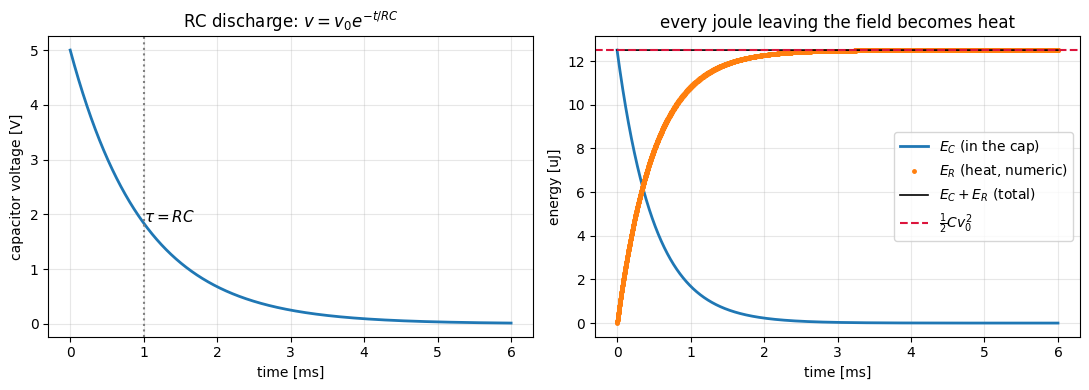

stored 1/2 C v0^2   =  12.50 uJ
dissipated (numeric)=  12.50 uJ
closed form E_R(inf)=  12.50 uJ


In [2]:
R, C, v0 = 1e3, 1e-6, 5.0            # 1 kohm, 1 uF, charged to 5 V
tau = R * C
t = np.linspace(0, 6 * tau, 4000)
v, i = ce.rc_discharge(R, C, v0, t)

E_cap    = ce.capacitor_energy(C, v)         # energy still in the cap
E_heat   = ce.dissipated_energy(i, R, t)     # cumulative heat in R (trapezoid)
E_stored = 0.5 * C * v0**2

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t*1e3, v, lw=2); ax[0].axvline(tau*1e3, ls=":", color="gray")
ax[0].annotate("$\\tau=RC$", (tau*1e3, v0*0.37), fontsize=11)
ax[0].set(xlabel="time [ms]", ylabel="capacitor voltage [V]",
          title="RC discharge: $v=v_0e^{-t/RC}$"); ax[0].grid(alpha=0.3)

ax[1].plot(t*1e3, E_cap*1e6, lw=2, label="$E_C$ (in the cap)")
ax[1].plot(t*1e3, E_heat*1e6, "o", ms=2.5, label="$E_R$ (heat, numeric)")
ax[1].plot(t*1e3, (E_cap+E_heat)*1e6, lw=1.2, color="k", label="$E_C+E_R$ (total)")
ax[1].axhline(E_stored*1e6, ls="--", color="crimson", label="$\\frac{1}{2} Cv_0^2$")
ax[1].set(xlabel="time [ms]", ylabel="energy [uJ]",
          title="every joule leaving the field becomes heat"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"stored 1/2 C v0^2   = {E_stored*1e6:6.2f} uJ")
print(f"dissipated (numeric)= {E_heat[-1]*1e6:6.2f} uJ")
print(f"closed form E_R(inf)= {ce.rc_energy_released(R,C,v0,t)[-1]*1e6:6.2f} uJ")

## 2. LC -- energy that sloshes and is never lost

Remove the resistor ($R=0$) and wire the charged capacitor straight to an
inductor. Now there is nowhere for energy to go, so it **oscillates between the
two tanks** -- electric field to magnetic field and back -- exactly like a
pendulum trading potential for kinetic energy. The sum $E_C+E_L$ is a flat line.

We get the transient from the *same* `spice.rlc_step_response`, just with $R=0$
and $V=0$ (a charged cap, released). The energy audit reports the conservation
drift -- how flat that total really is.

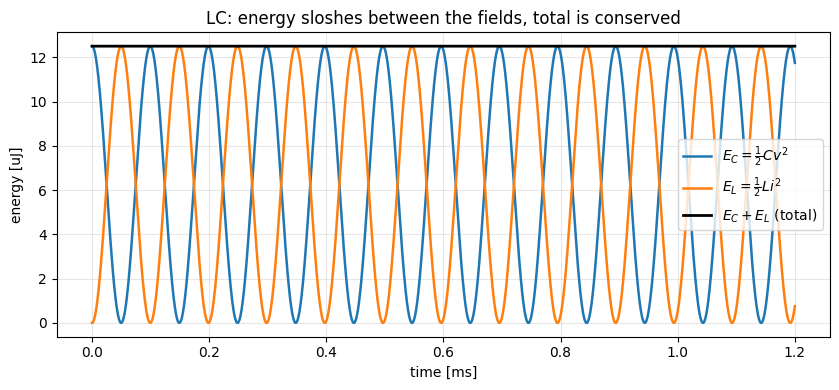

E0 = 12.500 uJ,  conservation drift = 3.7e-14
resonant frequency f0 = 1/(2*pi*sqrt(LC)) = 5033 Hz


In [3]:
L = 1e-3                               # 1 mH
t2 = np.linspace(0, 1.2e-3, 20000)
vc, iL = spice.rlc_step_response(0.0, L, C, t2, V=0.0, vc0=v0, il0=0.0)
audit = ce.energy_audit(0.0, L, C, t2, vc, iL)

plt.figure(figsize=(8.5, 4))
plt.plot(t2*1e3, audit["E_C"]*1e6, lw=1.8, label="$E_C=\\frac{1}{2}Cv^2$")
plt.plot(t2*1e3, audit["E_L"]*1e6, lw=1.8, label="$E_L=\\frac{1}{2}Li^2$")
plt.plot(t2*1e3, audit["total"]*1e6, "k", lw=2, label="$E_C+E_L$ (total)")
plt.xlabel("time [ms]"); plt.ylabel("energy [uJ]")
plt.title("LC: energy sloshes between the fields, total is conserved")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"E0 = {audit['E0']*1e6:.3f} uJ,  conservation drift = {audit['max_drift']:.1e}")
print(f"resonant frequency f0 = 1/(2*pi*sqrt(LC)) = {spice.resonant_frequency(L,C):.0f} Hz")

## 3. RLC -- the ring, and where the energy actually goes

Put the resistor back and you have the real thing: a charged cap discharging
through $R$ and $L$. The characteristic equation $s^2+\tfrac{R}{L}s+\tfrac1{LC}=0$
decides the personality:

* **underdamped** ($R<2\sqrt{L/C}$): complex roots -> it **rings** at the damped
  frequency $f_d=\tfrac1{2\pi}\sqrt{\tfrac1{LC}-(\tfrac{R}{2L})^2}$, a bit below $f_0$,
  while $R$ bleeds the energy away;
* **critically / over-damped**: real roots -> no oscillation, just a slump.

Whatever the regime, the first law holds *instant by instant*:
$$E_C(t)+E_L(t)+E_R(t)=E_0.$$
The stacked band below is that ledger: the shrinking coloured area is energy still
in the fields, the growing grey area is heat -- the top edge stays pinned at $E_0$.

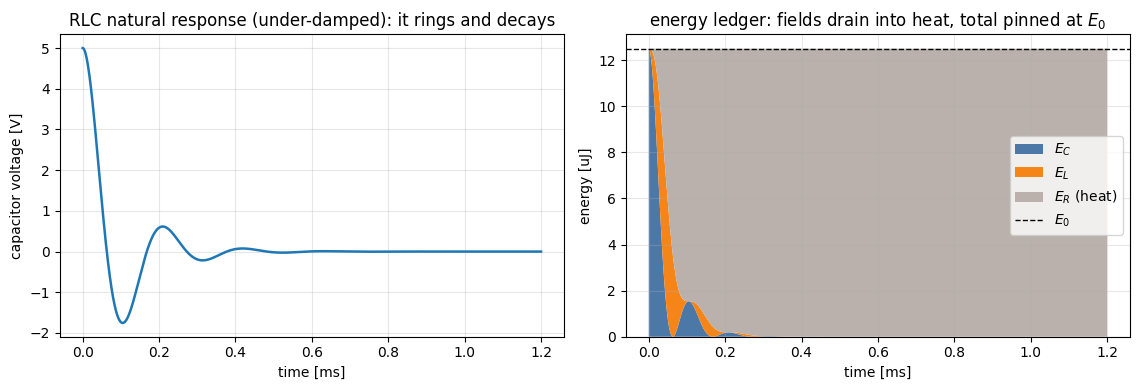

regime: under,  roots = [-10000.+30000.j -10000.-30000.j]
E0 = 12.50 uJ,  conservation drift = 2.0e-07
final energy still in fields = 0.000 uJ  ->  100.0% is now heat


In [4]:
R_ring = 20.0                          # underdamped
vc, iL = spice.rlc_step_response(R_ring, L, C, t2, V=0.0, vc0=v0, il0=0.0)
audit = ce.energy_audit(R_ring, L, C, t2, vc, iL)
regime, roots = spice.rlc_damping(R_ring, L, C)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
ax[0].plot(t2*1e3, vc, lw=1.8)
ax[0].set(xlabel="time [ms]", ylabel="capacitor voltage [V]",
          title=f"RLC natural response ({regime}-damped): it rings and decays")
ax[0].grid(alpha=0.3)

# stacked energy ledger: fields (shrinking) + heat (growing) = E0 (flat top)
ax[1].stackplot(t2*1e3, audit["E_C"]*1e6, audit["E_L"]*1e6, audit["E_R"]*1e6,
                labels=["$E_C$", "$E_L$", "$E_R$ (heat)"],
                colors=["#4C78A8", "#F58518", "#BAB0AC"])
ax[1].axhline(audit["E0"]*1e6, ls="--", color="k", lw=1, label="$E_0$")
ax[1].set(xlabel="time [ms]", ylabel="energy [uJ]",
          title="energy ledger: fields drain into heat, total pinned at $E_0$")
ax[1].legend(loc="center right"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"regime: {regime},  roots = {roots}")
print(f"E0 = {audit['E0']*1e6:.2f} uJ,  conservation drift = {audit['max_drift']:.1e}")
print(f"final energy still in fields = {(audit['E_C'][-1]+audit['E_L'][-1])*1e6:.3f} uJ"
      f"  ->  {audit['E_R'][-1]/audit['E0']*100:.1f}% is now heat")

## 4. Damping regimes -- one knob, three destinies

Sweep $R$ from tiny to large and the *same* wiring goes from a long ring, to the
fastest no-overshoot decay (**critical**, $R=2\sqrt{L/C}$), to a sluggish
over-damped slump. Critical damping is the sweet spot every mechanical latch,
meter movement, and control loop is tuned toward: quickest settle without ringing.

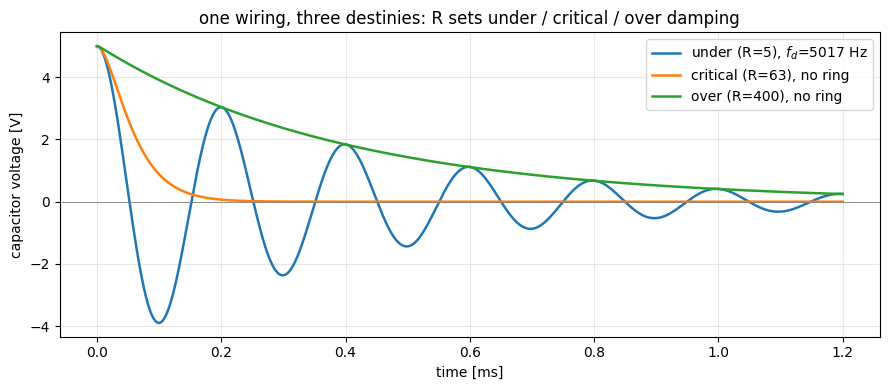

critical resistance R = 2*sqrt(L/C) = 63.2 ohm


In [5]:
Rc = spice.critical_resistance(L, C)   # 2 sqrt(L/C)
cases = [("under (R=5)", 5.0), (f"critical (R={Rc:.0f})", Rc), ("over (R=400)", 400.0)]
plt.figure(figsize=(9, 4))
for label, Rx in cases:
    vc, _ = spice.rlc_step_response(Rx, L, C, t2, V=0.0, vc0=v0, il0=0.0)
    fd = ce.damped_ring_frequency(Rx, L, C)
    tag = f"{label}, $f_d$={fd:.0f} Hz" if fd else f"{label}, no ring"
    plt.plot(t2*1e3, vc, lw=1.8, label=tag)
plt.axhline(0, color="gray", lw=0.6)
plt.xlabel("time [ms]"); plt.ylabel("capacitor voltage [V]")
plt.title("one wiring, three destinies: R sets under / critical / over damping")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"critical resistance R = 2*sqrt(L/C) = {Rc:.1f} ohm")

## 5. The ring in frequency -- closing the loop with the FFT

A decaying ring is a damped sinusoid, so its **spectrum peaks at the damped
natural frequency $f_d$** -- the same $f_d$ the energy audit rings at. We take the
FFT of the underdamped transient (the very `np.fft.fft` whose $x[0\!::\!2]/x[1\!::\!2]$
butterfly we proved in `dgs.strided_slicing`) and confirm the peak lands on the
$f_d$ our formula predicts. Storage, release, ring, spectrum -- one circuit,
audited end to end.

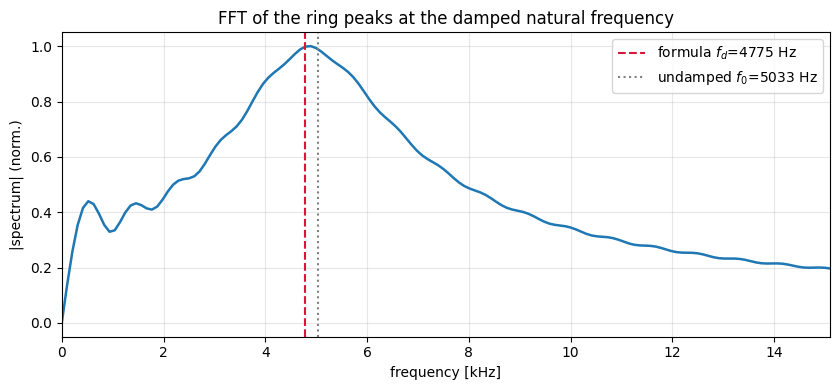

FFT peak = 4896 Hz   vs   formula f_d = 4775 Hz   (f0 = 5033 Hz)


In [6]:
vc, iL = spice.rlc_step_response(R_ring, L, C, t2, V=0.0, vc0=v0, il0=0.0)
dt = t2[1] - t2[0]
# zero-pad 8x so the bin spacing (~830 Hz raw) is fine enough to resolve
# f_d from the nearby undamped f0 -- otherwise the peak snaps to the wrong bin
nfft = 8 * len(vc)
spec  = np.abs(np.fft.rfft(vc - vc.mean(), n=nfft))
freqs = np.fft.rfftfreq(nfft, dt)
f_peak = freqs[np.argmax(spec)]
fd = ce.damped_ring_frequency(R_ring, L, C)
f0 = spice.resonant_frequency(L, C)

plt.figure(figsize=(8.5, 4))
plt.plot(freqs/1e3, spec/spec.max(), lw=1.8)
plt.axvline(fd/1e3, ls="--", color="crimson", label=f"formula $f_d$={fd:.0f} Hz")
plt.axvline(f0/1e3, ls=":", color="gray", label=f"undamped $f_0$={f0:.0f} Hz")
plt.xlim(0, 3*f0/1e3); plt.xlabel("frequency [kHz]"); plt.ylabel("|spectrum| (norm.)")
plt.title("FFT of the ring peaks at the damped natural frequency")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"FFT peak = {f_peak:.0f} Hz   vs   formula f_d = {fd:.0f} Hz   (f0 = {f0:.0f} Hz)")

## What we wired

* $E_C=\tfrac12Cv^2$ and $E_L=\tfrac12Li^2$ are the two energy tanks; a resistor
  dissipates at $i^2R\ge0$ and never returns energy.
* **RC discharge** turns *exactly* $\tfrac12Cv_0^2$ into heat, independent of $R$.
* **LC** conserves $E_C+E_L$ to ~$10^{-13}$ -- energy sloshes, none is lost.
* **RLC** obeys $E_C+E_L+E_R=E_0$ at every instant (drift ~$10^{-7}$); $R$ sets
  under/critical/over damping, and the underdamped **ring** shows up as a spectral
  peak at $f_d$ -- tying this back to the FFT/parity thread.

Same first law, three circuits: energy is stored in fields, released when you wire
a path, and accounted for down to the last microjoule.